In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv(
    "dataset/student_placement_prediction_dataset_2026.csv"
)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (100000, 26)


In [7]:
df.head(5)


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [8]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Column Names:
['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day', 'placement_status', 'salary_package_lpa']

Data Types:
student_id                     int64
age                            int64
gender                           str
cgpa                         float64
branch                           str
college_tier                     str
internships_count              int64
projects_count                 int64
certifications_count           int64
coding_skill_score           float64
aptitude_score               float64
communication_skill_score    float64
logical_reasoning_score    

Missing Values:
student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

Duplicate Rows: 0

Placement Distribution:
placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64


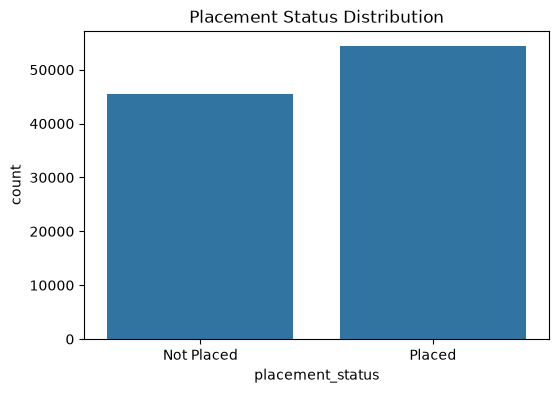

In [9]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nPlacement Distribution:")
print(df["placement_status"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="placement_status")
plt.title("Placement Status Distribution")
plt.show()

In [10]:
X = df.drop(
    ["placement_status", "student_id", "salary_package_lpa"],
    axis=1
)

y = df["placement_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (80000, 23)
Testing: (20000, 23)


In [17]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),
        (
            "numerical",
            "passthrough",
            numerical_columns
        )
    ]
)

# Three ML models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

trained_models = {}
predictions = {}

# Train models
for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline
    predictions[name] = pipeline.predict(X_test)

    print(name, "trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.5699,0.578748,0.772585,0.661765
1,Decision Tree,0.5496,0.569316,0.710338,0.632056
2,Random Forest,0.5577,0.574781,0.721906,0.639997


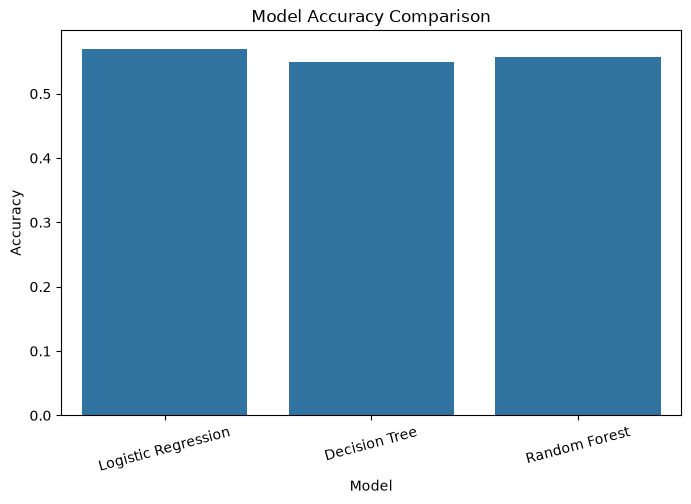

In [22]:
results = []

for name, pred in predictions.items():

    accuracy = accuracy_score(y_test, pred)

    precision = precision_score(
        y_test,
        pred,
        pos_label="Placed"
    )

    recall = recall_score(
        y_test,
        pred,
        pos_label="Placed"
    )

    f1 = f1_score(
        y_test,
        pred,
        pos_label="Placed"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

print("MODEL COMPARISON")
display(results_df)

# Accuracy graph
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.show()

Best Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.55      0.33      0.41      9108
      Placed       0.58      0.77      0.66     10892

    accuracy                           0.57     20000
   macro avg       0.56      0.55      0.54     20000
weighted avg       0.56      0.57      0.55     20000



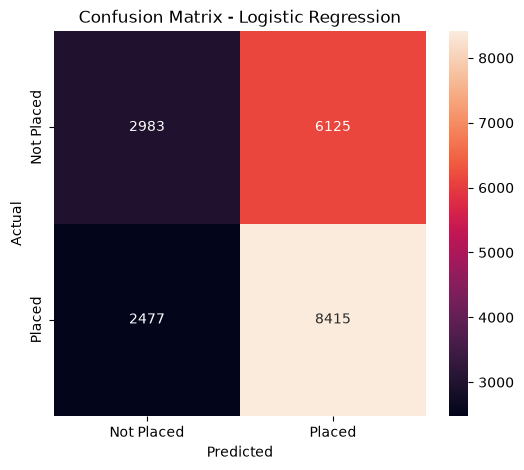

In [23]:
# Find best model
best_model_name = results_df.loc[
    results_df["Accuracy"].idxmax(),
    "Model"
]

best_model = trained_models[best_model_name]
best_prediction = predictions[best_model_name]

print("Best Model:", best_model_name)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_prediction
    )
)

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    best_prediction,
    labels=["Not Placed", "Placed"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
import os
import joblib

os.makedirs("model", exist_ok=True)

model_path = "model/placement_prediction_model.pkl"

joblib.dump(best_model, model_path)

print("Best model saved successfully!")
print("Model:", best_model_name)
print("Saved at:", model_path)

Best model saved successfully!
Model: Logistic Regression
Saved at: model/placement_prediction_model.pkl


In [26]:
# Create a new/unseen student
new_student = pd.DataFrame({
    "age": [21],
    "gender": ["Male"],
    "cgpa": [8.5],
    "branch": ["CSE"],
    "college_tier": ["Tier 1"],
    "internships_count": [2],
    "projects_count": [4],
    "certifications_count": [5],
    "coding_skill_score": [85],
    "aptitude_score": [82],
    "communication_skill_score": [80],
    "logical_reasoning_score": [84],
    "hackathons_participated": [2],
    "github_repos": [8],
    "linkedin_connections": [500],
    "mock_interview_score": [85],
    "attendance_percentage": [90],
    "backlogs": [0],
    "extracurricular_score": [75],
    "leadership_score": [70],
    "volunteer_experience": ["Yes"],
    "sleep_hours": [7],
    "study_hours_per_day": [4]
})

# Prediction
prediction = best_model.predict(new_student)

print("===================================")
print("     STUDENT PLACEMENT PREDICTION")
print("===================================")

print("Prediction:", prediction[0])

# Probability
if hasattr(best_model, "predict_proba"):
    probability = best_model.predict_proba(new_student)
    confidence = probability.max() * 100

    print(f"Confidence: {confidence:.2f}%")

print("===================================")

     STUDENT PLACEMENT PREDICTION
Prediction: Placed
Confidence: 72.62%


In [27]:
print("===================================")
print("     STUDENT PLACEMENT PREDICTION")
print("===================================")
print("Prediction:", prediction[0])
print(f"Confidence: {confidence:.2f}%")
print("===================================")

print("\nOpen prediction result:")
print("http://127.0.0.1:8000")

     STUDENT PLACEMENT PREDICTION
Prediction: Placed
Confidence: 72.62%

Open prediction result:
http://127.0.0.1:8000
